In [4]:
#importando as bibliotecas necessárias
import pandas as pd
import numpy as np


In [5]:
#Ler arquivo CSV da ISP RJ
df = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv', sep = ';')

In [6]:
#exibir 5 primeiras linhas do DataFrame
df.head(5)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3


In [7]:
#descrever o DataFrame
df.columns

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [8]:
#Agrupar por CISP(delegacias) e somar os furtos de celulares
df_furto_celular_dp = df.groupby('cisp')['furto_celular'].sum().reset_index()
df_furto_celular_dp = df_furto_celular_dp.sort_values(by='furto_celular', ascending=False)
df_furto_celular_dp.head(5)

,cisp,furto_celular
12,16,24879
2,5,23117
10,14,16945
8,12,16008
0,1,14968


In [9]:
#Criar um array  com os dados de furto de celular
array_furto_celular = np.array(df_furto_celular_dp['furto_celular'])

In [10]:
#Calcular as medidas estatísticas
media_furto_celular = np.mean(array_furto_celular)
mediana_furto_celular = np.median(array_furto_celular)
q1_furto_celular = np.quantile(array_furto_celular, 0.25)
q2_furto_celular = np.quantile(array_furto_celular, 0.50)
q3_furto_celular = np.quantile(array_furto_celular, 0.75)
iqr_furto_celular = q3_furto_celular - q1_furto_celular
limite_superior_furto_celular = q3_furto_celular + (1.5 * iqr_furto_celular)
limite_inferior_furto_celular = q1_furto_celular - (1.5 * iqr_furto_celular)

#Calcular a distancia entre media e mediana
distancia__furto_celular = (media_furto_celular -mediana_furto_celular) / mediana_furto_celular

#Exibir os resultados
print(f'A media é: {media_furto_celular}')
print(f'A mediana é: {mediana_furto_celular}')
print(f'O primeiro quartil (Q1) é : {q1_furto_celular}')
print(f'O segundo quartil (Q2, Mediana) é : {q2_furto_celular}')
print(f'O terceiro quartil (Q3) é : {q3_furto_celular}')
print(f'A distancia entre media e mediana é: {distancia__furto_celular}')
print(f'O limite superior é: {limite_superior_furto_celular}')
print(f'O limite inferior é: {limite_inferior_furto_celular}')

A media é: 3338.1159420289855
A mediana é: 1633.5
O primeiro quartil (Q1) é : 449.0
O segundo quartil (Q2, Mediana) é : 1633.5
O terceiro quartil (Q3) é : 4498.25
A distancia entre media e mediana é: 1.0435359302289473
O limite superior é: 10572.125
O limite inferior é: -5624.875


In [11]:
#Identificar outliers
outliers_furto_celular = df_furto_celular_dp.loc[df_furto_celular_dp['furto_celular'] > limite_superior_furto_celular]
outliers_furto_celular

,cisp,furto_celular
12,16,24879
2,5,23117
10,14,16945
8,12,16008
0,1,14968
5,9,14159
6,10,14105
1,4,13318
14,18,12939
28,32,12206


In [12]:
dp_furto_celular_acima_q3 = df_furto_celular_dp.loc[df_furto_celular_dp['furto_celular'] > q3_furto_celular]
print('Delegacias com os maiores furtos de celular :')
dp_furto_celular_acima_q3

Delegacias com os maiores furtos de celular :


,cisp,furto_celular
12,16,24879
2,5,23117
10,14,16945
8,12,16008
0,1,14968
5,9,14159
6,10,14105
1,4,13318
14,18,12939
28,32,12206


In [13]:
#Identificar delegacias com furtos de celular abaixo do primeiro quartil
dp_furto_celular_acima_q1 = df_furto_celular_dp.loc[df_furto_celular_dp['furto_celular'] < q1_furto_celular]
print('Delegacias com os menores furtos de celular :')
dp_furto_celular_acima_q1

Delegacias com os menores furtos de celular :


,cisp,furto_celular
99,121,448
90,107,443
84,99,431
85,100,387
7,11,385
60,67,364
79,94,361
115,139,360
86,101,352
111,135,351


In [14]:
#Agrupar por município e somar os estelionatos
df_estelionato = df.groupby('munic')['estelionato'].sum().reset_index()
df_estelionato = df_estelionato.sort_values(by='estelionato', ascending=False)
df_estelionato.head(5)

,munic,estelionato
68,Rio de Janeiro,606042
48,Niterói,50603
23,Duque de Caxias,41281
78,São Gonçalo,37222
50,Nova Iguaçu,36742


In [15]:
#Criar um array com os dados de estelionato
array_estelionato = np.array(df_estelionato['estelionato'])

In [16]:
#Calcular as medidas estatísticas
media_estelionato = np.mean(array_estelionato)
mediana_estelionato  = np.median(array_estelionato)
q1_estelionato  = np.quantile(array_estelionato, 0.25)
q2_estelionato  = np.quantile(array_estelionato, 0.50)
q3_estelionato  = np.quantile(array_estelionato, 0.75)

#Calcular a distancia entre media e mediana
distancia_estelionato  = (media_estelionato -mediana_estelionato) / mediana_estelionato

#Exibir os resultados
print(f'A media é: {media_estelionato}')
print(f'A mediana é: {mediana_estelionato}')
print(f'O primeiro quartil (Q1) é : {q1_estelionato}')
print(f'O segundo quartil (Q2, Mediana) é : {q2_estelionato}')
print(f'O terceiro quartil (Q3) é : {q3_estelionato}')
print(f'A distancia entre media e mediana é: {distancia_estelionato}')

A media é: 12167.655555555555
A mediana é: 1472.0
O primeiro quartil (Q1) é : 639.5
O segundo quartil (Q2, Mediana) é : 1472.0
O terceiro quartil (Q3) é : 7197.5
A distancia entre media e mediana é: 7.266070350241546


In [17]:
df_estelionato_q3 = df_estelionato.loc[df_estelionato['estelionato'] > q3_estelionato]
print('Os Municipios com os 25% maiores casos de estelionato são :')
df_estelionato_q3

Os Municipios com os 25% maiores casos de estelionato são :


,munic,estelionato
68,Rio de Janeiro,606042
48,Niterói,50603
23,Duque de Caxias,41281
78,São Gonçalo,37222
50,Nova Iguaçu,36742
81,São João de Meriti,23172
13,Campos dos Goytacazes,22142
54,Petrópolis,17251
36,Macaé,16577
89,Volta Redonda,16050


In [18]:
#Identificar municípios com estelionato abaixo do primeiro quartil
df_estelionato_q1 = df_estelionato.loc[df_estelionato['estelionato'] < q1_estelionato]
print('Municipios com os 25 % menores casos de estelionato são :')
df_estelionato_q1

Municipios com os 25 % menores casos de estelionato são :


,munic,estelionato
17,Carmo,637
39,Magé;Guapimirim,624
20,Conceição de Macabú,622
74,Silva Jardim,621
46,Natividade;Varre-Sai,547
71,Sapucaia,517
58,Porciúncula,517
79,São José do Vale do Rio Preto,468
65,Rio Claro,462
16,Cardoso Moreira;Italva,443


In [19]:
# Agrupar por município e somar as apreensões de menores
df_apreensao_menores = df.groupby('munic')['aaapai'].sum().reset_index()
df_apreensao_menores = df_apreensao_menores.sort_values(by='aaapai', ascending=False)
df_apreensao_menores.head(5)

,munic,aaapai
68,Rio de Janeiro,48246.0
78,São Gonçalo,7176.0
23,Duque de Caxias,6244.0
13,Campos dos Goytacazes,5468.0
48,Niterói,5316.0


In [20]:
#Criar um array com os dados de apreensao de menores
array_apreensao_menores = np.array(df_apreensao_menores['aaapai'])

In [21]:
#Calcular as medidas estatísticas
media_apreensao_menores = np.mean(array_apreensao_menores)
mediana_apreensao_menores = np.median(array_apreensao_menores)
q1_apreensao_menores = np.quantile(array_apreensao_menores, 0.25)
q2_apreensao_menores = np.quantile(array_apreensao_menores, 0.50)
q3_apreensao_menores = np.quantile(array_apreensao_menores, 0.75)

#Calcular a distancia entre media e mediana
distancia_apreensao_menores = (media_apreensao_menores - mediana_apreensao_menores) / mediana_apreensao_menores

#Exibir os resultados
print(f'A media é: {media_apreensao_menores}')
print(f'A mediana é: {mediana_apreensao_menores}')
print(f'O primeiro quartil (Q1) é : {q1_apreensao_menores}')
print(f'O segundo quartil (Q2, Mediana) é : {q2_apreensao_menores}')
print(f'O terceiro quartil (Q3) é : {q3_apreensao_menores}')
print(f'A distancia entre media e mediana é: {distancia_apreensao_menores}')

A media é: 1353.2444444444445
A mediana é: 297.5
O primeiro quartil (Q1) é : 86.0
O segundo quartil (Q2, Mediana) é : 297.5
O terceiro quartil (Q3) é : 934.25
A distancia entre media e mediana é: 3.5487208216619983


In [22]:
#Identificar municípios com apreensão de menores acima do terceiro quartil
df_apreensao_menores_q3 = df_apreensao_menores.loc[df_apreensao_menores['aaapai'] > q3_apreensao_menores]
print('Os Municipios com os 25% maiores casos de apreensão de menores são :')
df_apreensao_menores_q3

Os Municipios com os 25% maiores casos de apreensão de menores são :


,munic,aaapai
68,Rio de Janeiro,48246.0
78,São Gonçalo,7176.0
23,Duque de Caxias,6244.0
13,Campos dos Goytacazes,5468.0
48,Niterói,5316.0
50,Nova Iguaçu,4115.0
9,Cabo Frio,3111.0
81,São João de Meriti,2965.0
6,Belford Roxo,2605.0
89,Volta Redonda,2210.0


In [23]:
#Identificar municípios com apreensão de menores abaixo do primeiro quartil
df_apreensao_menores = df_apreensao_menores.loc[df_apreensao_menores['aaapai'] < q1_apreensao_menores]
print('Municipios com os 25 % menores casos de apreensão de menores são :')
df_apreensao_menores

Municipios com os 25 % menores casos de apreensão de menores são :


,munic,aaapai
88,Vassouras,80.0
21,Cordeiro;Macuco,73.0
17,Carmo,72.0
58,Porciúncula,62.0
16,Cardoso Moreira;Italva,61.0
15,Cantagalo,60.0
65,Rio Claro,45.0
46,Natividade;Varre-Sai,44.0
71,Sapucaia,44.0
12,Cambuci,38.0


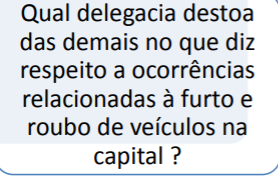

In [24]:
#Criar uma nova coluna com a soma de roubo de veículos e furto de veículos
df['roubo_furto_veiculo'] = df['roubo_veiculo'] + df['furto_veiculos']
df 

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,roubo_furto_veiculo
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,21,2,0,0,0,0,578,3,17
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,15,6,0,1,0,0,441,3,18
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,47,2,1,0,0,0,637,3,39
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,26,2,1,0,0,0,473,3,44
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,10,1,3,0,0,0,147,3,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36898,159,10,2025,2025m10,35,4,Cachoeiras de Macacu,3300803,Interior,1,...,0.0,37,2,0,0,0,0,163,2,1
36899,165,10,2025,2025m10,33,5,Mangaratiba,3302601,Interior,1,...,0.0,21,0,0,0,0,0,196,2,4
36900,166,10,2025,2025m10,33,5,Angra dos Reis,3300100,Interior,3,...,0.0,82,8,0,1,0,0,682,2,4
36901,167,10,2025,2025m10,43,5,Paraty,3303807,Interior,1,...,1.0,11,1,0,0,0,0,195,2,3


In [25]:
#localizar os dados da capital
df_capital_roubo_furto_veiculo = df.loc[df['regiao'] == 'Capital']

# Agrupar por CISP(delegacias) e somar os roubos e furtos de veículos pela coluna criada anteriormente
df_roubo_veiculo_rj = df_capital_roubo_furto_veiculo.groupby('cisp')['roubo_furto_veiculo'].sum().reset_index()
df_roubo_veiculo_rj = df_roubo_veiculo_rj.sort_values(by='roubo_furto_veiculo', ascending=False)
df_roubo_veiculo_rj.head(5)

,cisp,roubo_furto_veiculo
23,27,39024
30,34,36897
31,35,33436
35,39,32500
34,38,25999


In [26]:
#Criar um array com os dados de roubo e furto de veículos na capital
array_roubo_veiculo_rj = np.array(df_roubo_veiculo_rj['roubo_furto_veiculo'])

In [27]:
#Calcular as medidas estatísticas
media_roubo_furto_veiculo_rj = np.mean(array_roubo_veiculo_rj)
mediana_roubo_furto_veiculo_rj = np.median(array_roubo_veiculo_rj)
q1_roubo_furto_veiculo_rj = np.quantile(array_roubo_veiculo_rj, 0.25)
q2_roubo_furto_veiculo_rj = np.quantile(array_roubo_veiculo_rj, 0.50)
q3_roubo_furto_veiculo_rj = np.quantile(array_roubo_veiculo_rj, 0.75)
iqr_roubo_furto_veiculo_rj = q3_roubo_furto_veiculo_rj - q1_roubo_furto_veiculo_rj
limite_superior_roubo_furto_veiculo_rj = q3_roubo_furto_veiculo_rj + (1.5 * iqr_roubo_furto_veiculo_rj)
limite_inferior_roubo_furto_veiculo_rj = q1_roubo_furto_veiculo_rj - (1.5 * iqr_roubo_furto_veiculo_rj)

#Calcular a distancia entre media e mediana
distancia_roubo_furto_veiculo_rj = (media_roubo_furto_veiculo_rj - mediana_roubo_furto_veiculo_rj) / mediana_roubo_furto_veiculo_rj

#Exibir os resultados
print(f'A media é: {media_roubo_furto_veiculo_rj}')
print(f'A mediana é: {mediana_roubo_furto_veiculo_rj}')
print(f'O primeiro quartil (Q1) é : {q1_roubo_furto_veiculo_rj}')
print(f'O segundo quartil (Q2, Mediana) é : {q2_roubo_furto_veiculo_rj}')
print(f'O terceiro quartil (Q3) é : {q3_roubo_furto_veiculo_rj}')
print(f'A distancia entre media e mediana é: {distancia_roubo_furto_veiculo_rj}')
print(f'O limite superior é: {limite_superior_roubo_furto_veiculo_rj}')
print(f'O limite inferior é: {limite_inferior_roubo_furto_veiculo_rj}')

A media é: 13949.333333333334
A mediana é: 12701.0
O primeiro quartil (Q1) é : 5015.25
O segundo quartil (Q2, Mediana) é : 12701.0
O terceiro quartil (Q3) é : 18068.75
A distancia entre media e mediana é: 0.098286224181823
O limite superior é: 37649.0
O limite inferior é: -14565.0


In [28]:
#Identificar outliers
outliers_roubo_furto_veiculo_rj = df_roubo_veiculo_rj.loc[df_roubo_veiculo_rj['roubo_furto_veiculo'] > limite_superior_roubo_furto_veiculo_rj]
outliers_roubo_furto_veiculo_rj

,cisp,roubo_furto_veiculo
23,27,39024


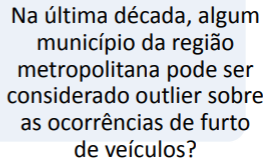

In [29]:
#Lista dos municípios que compõem a região do Grande Rio
municipios_metropole_rio = [
    "Belford Roxo", "Cachoeiras de Macacu", "Duque de Caxias", "Guapimirim",
    "Itaboraí", "Itaguaí", "Japeri", "Magé", "Maricá", "Mesquita",
    "Nilópolis", "Niterói", "Nova Iguaçu", "Paracambi", "Petrópolis",
    "Queimados", "Rio Bonito", "Rio de Janeiro", "São Gonçalo",
    "São João de Meriti", "Seropédica", "Tanguá"
]

In [ ]:
#Filtrar o DataFrame original para incluir apenas os municípios da região metropolitana do Rio de Janeiro
df_metropole_furto_veiculo = df.loc[(df['munic'] .isin(municipios_metropole_rio))]
df_metropole_furto_veiculo = df_metropole_furto_veiculo.loc[df_metropole_furto_veiculo['ano'] >= 2015]  
df_metropole_furto_veiculo

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,roubo_furto_veiculo
19045,1,1,2015,2015m01,5,1,Rio de Janeiro,3304557,Capital,0,...,0.0,11,1,0,0,0,0,992,3,2
19046,4,1,2015,2015m01,5,1,Rio de Janeiro,3304557,Capital,1,...,1.0,16,7,0,0,0,0,1278,3,11
19047,5,1,2015,2015m01,5,1,Rio de Janeiro,3304557,Capital,1,...,1.0,35,1,0,0,0,0,1231,3,13
19048,6,1,2015,2015m01,4,1,Rio de Janeiro,3304557,Capital,3,...,0.0,20,2,1,0,1,0,461,3,13
19049,7,1,2015,2015m01,5,1,Rio de Janeiro,3304557,Capital,0,...,0.0,19,0,0,0,0,0,239,3,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36837,82,10,2025,2025m10,12,4,Maricá,3302700,Grande Niterói,2,...,0.0,107,8,0,2,0,0,981,2,12
36853,105,10,2025,2025m10,26,7,Petrópolis,3303906,Interior,1,...,0.0,89,5,0,0,0,0,845,2,4
36854,106,10,2025,2025m10,26,7,Petrópolis,3303906,Interior,0,...,0.0,56,4,0,0,0,0,474,2,7
36862,119,10,2025,2025m10,35,4,Rio Bonito,3304300,Interior,2,...,1.0,15,3,1,0,0,0,231,2,8


In [41]:
df_metropole_furto_veiculo = df_metropole_furto_veiculo.groupby('munic')['furto_veiculos'].sum().reset_index()
df_metropole_furto_veiculo = df_metropole_furto_veiculo.sort_values(by='furto_veiculos', ascending=False)
df_metropole_furto_veiculo

,munic,furto_veiculos
17,Rio de Janeiro,78688
19,São Gonçalo,12459
2,Duque de Caxias,11506
12,Nova Iguaçu,10269
11,Niterói,7339
20,São João de Meriti,5858
0,Belford Roxo,4404
9,Mesquita,2479
7,Magé,2433
4,Itaboraí,2407


In [35]:
array_metropole_furto_veiculo=np.array(df_metropole_furto_veiculo['furto_veiculos'])

In [36]:
#Calcular as medidas estatísticas
media_metropole_furto_veiculo = np.mean(array_metropole_furto_veiculo)
media_metropole_furto_veiculo = np.median(array_metropole_furto_veiculo)
q1_metropole_furto_veiculo = np.quantile(array_metropole_furto_veiculo, 0.25)
q2_metropole_furto_veiculo = np.quantile(array_metropole_furto_veiculo, 0.50)
q3_metropole_furto_veiculo = np.quantile(array_metropole_furto_veiculo, 0.75)
iqr_metropole_furto_veiculo = q3_metropole_furto_veiculo - q1_metropole_furto_veiculo
limite_superior_metropole_furto_veiculo = q3_metropole_furto_veiculo + (1.5 * iqr_metropole_furto_veiculo   )
limite_inferior_metropole_furto_veiculo = q1_metropole_furto_veiculo - (1.5 * iqr_metropole_furto_veiculo   )

#Calcular a distancia entre media e mediana
distancia_metropole_furto_veiculo = (media_metropole_furto_veiculo - media_metropole_furto_veiculo) / media_metropole_furto_veiculo

#Exibir os resultados
print(f'A media é: {media_metropole_furto_veiculo}')
print(f'A mediana é: {media_metropole_furto_veiculo}')
print(f'O primeiro quartil (Q1) é : {q1_metropole_furto_veiculo}')
print(f'O segundo quartil (Q2, Mediana) é : {q2_metropole_furto_veiculo}')
print(f'O terceiro quartil (Q3) é : {q3_metropole_furto_veiculo}')
print(f'A distancia entre media e mediana é: {distancia_metropole_furto_veiculo}')
print(f'O limite superior é: {limite_superior_metropole_furto_veiculo}')
print(f'O limite inferior é: {limite_inferior_roubo_furto_veiculo_rj}')

A media é: 2126.0
A mediana é: 2126.0
O primeiro quartil (Q1) é : 721.75
O segundo quartil (Q2, Mediana) é : 2126.0
O terceiro quartil (Q3) é : 5494.5
A distancia entre media e mediana é: 0.0
O limite superior é: 12653.625
O limite inferior é: -14565.0


In [40]:
#Identificar outliers
outliers_metropole_furto_veiculo = df_metropole_furto_veiculo.loc[df_metropole_furto_veiculo['furto_veiculos'] > limite_superior_metropole_furto_veiculo]
outliers_metropole_furto_veiculo

,munic,furto_veiculos
17,Rio de Janeiro,78688
